# HOGENOM likelihood optimization

This notebook uses the lean `GeneReconModel` API to load the HOGENOM species tree and gene-tree distributions, evaluate the full negative log-likelihood, and optimize the likelihood end to end with Adam.

Set `MODE` to `global`, `specieswise`, or `genewise`.

In [1]:
from pathlib import Path
import json
import math
import os
import subprocess
import time

import sys

import torch

CWD = Path.cwd()
REPO = CWD if (CWD / "gpurec").exists() else CWD.parent if (CWD.parent / "gpurec").exists() else CWD
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from gpurec import GeneReconModel, SolverOptions, clamp_log_rate_, project_rate_gradient_

torch.set_float32_matmul_precision("high")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE != "cuda":
    raise RuntimeError("The current lean HOGENOM likelihood path requires CUDA/Triton.")
DEVICE

'cuda'

## Paths and run settings

In [2]:
def find_hogenom_root() -> Path:
    env_root = os.environ.get("HOGENOM_ROOT")
    candidates = []
    if env_root:
        candidates.append(Path(env_root).expanduser())
    candidates.extend([
        REPO / "tests/data",
        REPO / "tests/data/HOGENOM/hogenom",
        REPO / "tests/data/HOGENOM",
        REPO / "tests/data/hogenom",
        REPO / "data/HOGENOM/hogenom",
    ])
    for candidate in candidates:
        if (candidate / "hogenom_S.tree").exists() and (candidate / "hogenom_trees").is_dir():
            return candidate
    raise FileNotFoundError(
        "Set HOGENOM_ROOT, or set both HOGENOM_SPECIES_TREE and "
        "HOGENOM_GENE_TREE_DIR, before running this notebook."
    )

species_tree_env = os.environ.get("HOGENOM_SPECIES_TREE")
gene_tree_dir_env = os.environ.get("HOGENOM_GENE_TREE_DIR")
if species_tree_env or gene_tree_dir_env:
    if not (species_tree_env and gene_tree_dir_env):
        raise ValueError("Set both HOGENOM_SPECIES_TREE and HOGENOM_GENE_TREE_DIR, or neither.")
    SPECIES_TREE = Path(species_tree_env).expanduser()
    GENE_TREE_DIR = Path(gene_tree_dir_env).expanduser()
    HOGENOM_ROOT = GENE_TREE_DIR.parent
else:
    HOGENOM_ROOT = find_hogenom_root()
    SPECIES_TREE = HOGENOM_ROOT / "hogenom_S.tree"
    GENE_TREE_DIR = HOGENOM_ROOT / "hogenom_trees"

MODE = os.environ.get("GPUREC_MODE", "specieswise")  # global, specieswise, or genewise
MAX_FAMILIES = None  # set to an int for a fast smoke run

STEPS = 1000
LR = 1
PRINT_EVERY = 10
CLIP_GRAD_NORM = 1_000.0
MIN_RATE = 1e-10
MAX_RATE = 2.0
OPTIMIZER_NAME = "Adam"  # Adam or Adagrad

# Adaptive solver controls. When the loss stalls, increase solver accuracy
# and reset optimizer state so stale moments do not dominate the new regime.
STALL_PATIENCE = 20
STALL_REL_IMPROVEMENT = 1e-3
STALL_ABS_IMPROVEMENT = 0.0
PI_ITERS_INCREMENT = 4
PI_ITERS_MAX = 32
NEUMANN_TERMS_INCREMENT = 4
NEUMANN_TERMS_MAX = 32
RESET_OPTIMIZER_ON_STALL = True

# Solver controls. These can also be changed during optimization with
# model.configure_solver(...) or direct model.solver_options.* assignment.
E_INIT = -1000
E_MAX_ITER = 2000
E_TOL = 1e-8
PI_ITERS = 6
NEUMANN_TERMS = 6
BICGSTAB_MAX_ITER = 500
BICGSTAB_TOL = 1e-7
BICGSTAB_BREAKDOWN_TOL = 1e-30
ADJOINT_PRUNING_THRESHOLD = 1e-6
USE_ADJOINT_PRUNING = True
PIBAR_SIDE_THRESHOLD = 0.0

species_tree = SPECIES_TREE
gene_trees = sorted(GENE_TREE_DIR.glob("*.trees"))
if MAX_FAMILIES is not None:
    gene_trees = gene_trees[:MAX_FAMILIES]

if not species_tree.exists():
    raise FileNotFoundError(f"species tree not found: {species_tree}")
if not gene_trees:
    raise FileNotFoundError(f"no *.trees files found in {GENE_TREE_DIR}")

{
    "mode": MODE,
    "device": DEVICE,
    "species_tree": str(species_tree),
    "gene_tree_dir": str(GENE_TREE_DIR),
    "families": len(gene_trees),
    "min_rate": MIN_RATE,
    "max_rate": MAX_RATE,
    "optimizer": OPTIMIZER_NAME,
    "stall_patience": STALL_PATIENCE,
    "solver": {
        "e_max_iter": E_MAX_ITER,
        "e_tol": E_TOL,
        "pi_iters": PI_ITERS,
        "neumann_terms": NEUMANN_TERMS,
        "bicgstab_max_iter": BICGSTAB_MAX_ITER,
        "bicgstab_tol": BICGSTAB_TOL,
    },
}

{'mode': 'specieswise',
 'device': 'cuda',
 'species_tree': '/home/enzo/Documents/git/gpurec/gpurec/tests/data/hogenom_S.tree',
 'gene_tree_dir': '/home/enzo/Documents/git/gpurec/gpurec/tests/data/hogenom_trees',
 'families': 1055,
 'min_rate': 1e-10,
 'max_rate': 2.0,
 'optimizer': 'Adam',
 'stall_patience': 20,
 'solver': {'e_max_iter': 2000,
  'e_tol': 1e-08,
  'pi_iters': 6,
  'neumann_terms': 6,
  'bicgstab_max_iter': 500,
  'bicgstab_tol': 1e-07}}

## Native extension check

In [3]:
preprocess_so = REPO / "crates/gpurec-preprocess/target/release/libgpurec_preprocess.so"

if not preprocess_so.exists():
    subprocess.run(["cargo", "build", "--release"], cwd=REPO / "crates/gpurec-preprocess", check=True)

preprocess_so.exists()

True

## Build the model

In [4]:
torch.cuda.empty_cache()
if DEVICE == "cuda":
    torch.cuda.reset_peak_memory_stats()

t0 = time.perf_counter()
solver_options = SolverOptions(
    e_init=E_INIT,
    e_max_iter=E_MAX_ITER,
    e_tol=E_TOL,
    pi_iters=PI_ITERS,
    neumann_terms=NEUMANN_TERMS,
    bicgstab_max_iter=BICGSTAB_MAX_ITER,
    bicgstab_tol=BICGSTAB_TOL,
    bicgstab_breakdown_tol=BICGSTAB_BREAKDOWN_TOL,
    adjoint_pruning_threshold=ADJOINT_PRUNING_THRESHOLD,
    use_adjoint_pruning=USE_ADJOINT_PRUNING,
    pibar_side_threshold=PIBAR_SIDE_THRESHOLD,
)
model = GeneReconModel(
    species_tree,
    gene_trees,
    mode=MODE,
    device=DEVICE,
    family_chunk_size=300,
    clade_budget=315_000,
    batch_packing="depth_first_fit",
    max_wave_size=8192,
    solver_options=solver_options,
)
clamp_log_rate_(model.theta, min_rate=MIN_RATE, max_rate=MAX_RATE)
if DEVICE == "cuda":
    torch.cuda.synchronize()
build_s = time.perf_counter() - t0

{
    "build_s": build_s,
    "theta_shape": tuple(model.theta.shape),
    "batches": [len(batch) for batch in model.family_batches],
    "waves": [len(static.wave_layout["wave_metas"]) for static in model.batch_statics],
    "solver_options": model.solver_options.__dict__,
}

{'build_s': 7.351877139881253,
 'theta_shape': (1325, 3),
 'batches': [91, 146, 300, 300, 218],
 'waves': [102, 65, 48, 30, 13],
 'solver_options': {'e_init': -1000,
  'e_max_iter': 2000,
  'e_tol': 1e-08,
  'pi_iters': 6,
  'neumann_terms': 6,
  'bicgstab_max_iter': 500,
  'bicgstab_tol': 1e-07,
  'bicgstab_breakdown_tol': 1e-30,
  'adjoint_pruning_threshold': 1e-06,
  'use_adjoint_pruning': True,
  'pibar_side_threshold': 0.0}}

## Initial likelihood and gradient

In [5]:
model.zero_grad(set_to_none=True)
t0 = time.perf_counter()
loss0 = model()
loss0.backward()
if DEVICE == "cuda":
    torch.cuda.synchronize()
eval_s = time.perf_counter() - t0

grad_norm0 = float(model.theta.grad.detach().norm().cpu())
peak_gib = torch.cuda.max_memory_allocated() / 1024**3 if DEVICE == "cuda" else None

{
    "initial_nll_bits": float(loss0.detach().cpu()),
    "grad_norm": grad_norm0,
    "eval_s": eval_s,
    "peak_gib": peak_gib,
}

{'initial_nll_bits': 2305222.25,
 'grad_norm': 1992.7667236328125,
 'eval_s': 1.768797046970576,
 'peak_gib': 5.898375034332275}

## Optimize

In [ ]:
def make_optimizer(name, params, *, lr):
    name = str(name).strip().lower()
    if name == "adam":
        return torch.optim.Adam(params, lr=lr)
    if name == "adagrad":
        return torch.optim.Adagrad(params, lr=lr)
    raise ValueError(f"unsupported optimizer {name!r}; use 'Adam' or 'Adagrad'")


def bump_solver_options(
    model,
    *,
    pi_increment,
    pi_max,
    neumann_increment,
    neumann_max,
):
    old_pi = int(model.solver_options.pi_iters)
    old_neumann = int(model.solver_options.neumann_terms)
    pi_cap = int(pi_max)
    if pi_cap % 2:
        pi_cap -= 1
    pi_cap = max(2, pi_cap)
    new_pi = min(pi_cap, old_pi + int(pi_increment))
    if new_pi % 2:
        new_pi += 1
    new_pi = min(pi_cap, new_pi)
    new_neumann = min(int(neumann_max), old_neumann + int(neumann_increment))
    changed = new_pi != old_pi or new_neumann != old_neumann
    if changed:
        model.configure_solver(pi_iters=new_pi, neumann_terms=new_neumann)
        model.clear_warm_starts()
    return {
        "solver_changed": changed,
        "old_pi_iters": old_pi,
        "new_pi_iters": int(model.solver_options.pi_iters),
        "old_neumann_terms": old_neumann,
        "new_neumann_terms": int(model.solver_options.neumann_terms),
    }


def should_increase_solver(history, *, patience, rel_improvement, abs_improvement):
    if patience <= 0 or len(history) <= patience:
        return False, None
    earlier = history[-patience - 1]["nll_bits"]
    current = history[-1]["nll_bits"]
    improvement = earlier - current
    required = max(float(abs_improvement), float(rel_improvement) * max(abs(earlier), 1.0))
    return improvement <= required, {
        "window_improvement_bits": improvement,
        "required_improvement_bits": required,
        "window_start_nll_bits": earlier,
    }


def optimize_likelihood_adaptive_solver(
    model,
    *,
    steps,
    optimizer_name="Adam",
    lr=1.0,
    clip_grad_norm,
    min_rate,
    max_rate,
    stall_patience,
    stall_rel_improvement,
    stall_abs_improvement,
    pi_iters_increment,
    pi_iters_max,
    neumann_terms_increment,
    neumann_terms_max,
    reset_optimizer_on_stall=True,
    print_every=10,
):
    optimizer = make_optimizer(optimizer_name, [model.theta], lr=lr)
    clamp_log_rate_(model.theta, min_rate=min_rate, max_rate=max_rate)
    history = []
    previous_loss = None
    optimizer_reset_count = 0
    last_solver_adjust_step = 0

    for step in range(1, int(steps) + 1):
        optimizer.zero_grad(set_to_none=True)
        t0 = time.perf_counter()
        loss = model()
        loss.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_([model.theta], clip_grad_norm)
        project_rate_gradient_(model.theta, min_rate=min_rate, max_rate=max_rate)
        projected_grad_norm = float(model.theta.grad.detach().norm().cpu())
        optimizer.step()
        clamp_log_rate_(model.theta, min_rate=min_rate, max_rate=max_rate)
        if DEVICE == "cuda":
            torch.cuda.synchronize()
        step_s = time.perf_counter() - t0

        loss_value = float(loss.detach().cpu())
        delta = None if previous_loss is None else loss_value - previous_loss
        previous_loss = loss_value
        row = {
            "step": step,
            "nll_bits": loss_value,
            "delta_bits": delta,
            "grad_norm": float(torch.as_tensor(grad_norm).detach().cpu()),
            "projected_grad_norm": projected_grad_norm,
            "theta_min": float(model.theta.detach().min().cpu()),
            "theta_max": float(model.theta.detach().max().cpu()),
            "e_max_iter": model.solver_options.e_max_iter,
            "e_tol": model.solver_options.e_tol,
            "pi_iters": model.solver_options.pi_iters,
            "neumann_terms": model.solver_options.neumann_terms,
            "bicgstab_max_iter": model.solver_options.bicgstab_max_iter,
            "bicgstab_tol": model.solver_options.bicgstab_tol,
            "lr": optimizer.param_groups[0]["lr"],
            "optimizer": optimizer_name,
            "optimizer_reset_count": optimizer_reset_count,
            "solver_changed": False,
            "step_s": step_s,
        }
        history.append(row)

        if step - last_solver_adjust_step >= stall_patience:
            stalled, stall_info = should_increase_solver(
                history,
                patience=stall_patience,
                rel_improvement=stall_rel_improvement,
                abs_improvement=stall_abs_improvement,
            )
        else:
            stalled, stall_info = False, None
        if stalled:
            bump = bump_solver_options(
                model,
                pi_increment=pi_iters_increment,
                pi_max=pi_iters_max,
                neumann_increment=neumann_terms_increment,
                neumann_max=neumann_terms_max,
            )
            if bump["solver_changed"] and reset_optimizer_on_stall:
                optimizer = make_optimizer(optimizer_name, [model.theta], lr=lr)
                optimizer_reset_count += 1
            if bump["solver_changed"]:
                last_solver_adjust_step = step
            row.update(bump)
            row.update(stall_info or {})
            row["pi_iters"] = model.solver_options.pi_iters
            row["neumann_terms"] = model.solver_options.neumann_terms
            row["optimizer_reset_count"] = optimizer_reset_count

        if step == 1 or step % print_every == 0 or row["solver_changed"]:
            print(
                f"step={step:04d} nll={loss_value:.6f} "
                f"delta={delta if delta is not None else float('nan'):.6f} "
                f"grad_norm={row['grad_norm']:.3g} "
                f"projected_grad_norm={row['projected_grad_norm']:.3g} "
                f"pi={model.solver_options.pi_iters} "
                f"neumann={model.solver_options.neumann_terms} "
                f"resets={optimizer_reset_count} "
                f"step_s={step_s:.3f}"
            )

    return history


history = optimize_likelihood_adaptive_solver(
    model,
    steps=STEPS,
    optimizer_name=OPTIMIZER_NAME,
    lr=2 * LR,
    clip_grad_norm=CLIP_GRAD_NORM,
    min_rate=MIN_RATE,
    max_rate=MAX_RATE,
    stall_patience=STALL_PATIENCE,
    stall_rel_improvement=STALL_REL_IMPROVEMENT,
    stall_abs_improvement=STALL_ABS_IMPROVEMENT,
    pi_iters_increment=PI_ITERS_INCREMENT,
    pi_iters_max=PI_ITERS_MAX,
    neumann_terms_increment=NEUMANN_TERMS_INCREMENT,
    neumann_terms_max=NEUMANN_TERMS_MAX,
    reset_optimizer_on_stall=RESET_OPTIMIZER_ON_STALL,
    print_every=PRINT_EVERY,
)

history[-1] if history else None

step=0001 nll=2305222.250000 delta=nan grad_norm=1.99e+03 projected_grad_norm=1e+03 pi=6 neumann=6 resets=0 step_s=0.980
step=0010 nll=1283132.750000 delta=-114562.000000 grad_norm=1.96e+03 projected_grad_norm=1e+03 pi=6 neumann=6 resets=0 step_s=0.971
step=0020 nll=634837.625000 delta=-690.062500 grad_norm=2.12e+03 projected_grad_norm=931 pi=6 neumann=6 resets=0 step_s=1.235
step=0030 nll=553597.437500 delta=195.375000 grad_norm=693 projected_grad_norm=558 pi=6 neumann=6 resets=0 step_s=1.147
step=0040 nll=544071.125000 delta=-887.312500 grad_norm=732 projected_grad_norm=520 pi=6 neumann=6 resets=0 step_s=1.155
step=0050 nll=539693.375000 delta=-157.875000 grad_norm=617 projected_grad_norm=328 pi=6 neumann=6 resets=0 step_s=1.148
step=0060 nll=537961.250000 delta=-141.375000 grad_norm=560 projected_grad_norm=180 pi=6 neumann=6 resets=0 step_s=1.435
step=0070 nll=537222.250000 delta=-29.500000 grad_norm=541 projected_grad_norm=117 pi=6 neumann=6 resets=0 step_s=1.141
step=0080 nll=5368

In [ ]:
history

[{'step': 1,
  'nll_bits': 2305222.25,
  'delta_bits': None,
  'grad_norm': 1992.7667236328125,
  'projected_grad_norm': 1000.0000610351562,
  'theta_min': -33.21928024291992,
  'theta_max': -31.219280242919922,
  'e_max_iter': 2000,
  'e_tol': 1e-08,
  'pi_iters': 6,
  'neumann_terms': 3,
  'bicgstab_max_iter': 500,
  'bicgstab_tol': 1e-07,
  'lr': 2,
  'optimizer': 'Adam',
  'optimizer_reset_count': 0,
  'solver_changed': False,
  'step_s': 0.8395458289887756},
 {'step': 2,
  'nll_bits': 2192137.75,
  'delta_bits': -113084.5,
  'grad_norm': 1992.1978759765625,
  'projected_grad_norm': 1000.0000610351562,
  'theta_min': -33.21928024291992,
  'theta_max': -29.216564178466797,
  'e_max_iter': 2000,
  'e_tol': 1e-08,
  'pi_iters': 6,
  'neumann_terms': 3,
  'bicgstab_max_iter': 500,
  'bicgstab_tol': 1e-07,
  'lr': 2,
  'optimizer': 'Adam',
  'optimizer_reset_count': 0,
  'solver_changed': False,
  'step_s': 0.8446174040436745},
 {'step': 3,
  'nll_bits': 2078999.375,
  'delta_bits': -11

## Plot the trace

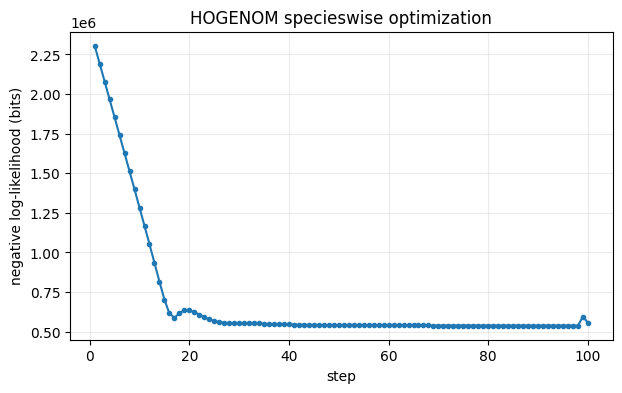

In [ ]:
try:
    import matplotlib.pyplot as plt

    steps = [row["step"] for row in history]
    values = [row["nll_bits"] for row in history]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(steps, values, marker=".")
    ax.set_xlabel("step")
    ax.set_ylabel("negative log-likelihood (bits)")
    ax.set_title(f"HOGENOM {MODE} optimization")
    ax.grid(alpha=0.25)
    plt.show()
except ImportError:
    print("matplotlib is not installed; skipping plot")

## Inspect fitted event probabilities

In [ ]:
def event_probabilities(theta: torch.Tensor) -> torch.Tensor:
    theta_cpu = theta.detach().cpu()
    zeros = torch.zeros((*theta_cpu.shape[:-1], 1), dtype=theta_cpu.dtype)
    logits = torch.cat((zeros, theta_cpu), dim=-1)
    return torch.softmax(logits * math.log(2.0), dim=-1)

probs = event_probabilities(model.theta)
labels = ["pT", "pS", "pD", "pL"]

if probs.ndim == 1:
    dict(zip(labels, [float(x) for x in probs]))
else:
    summary = {
        label: {
            "mean": float(probs[..., i].mean()),
            "min": float(probs[..., i].min()),
            "max": float(probs[..., i].max()),
        }
        for i, label in enumerate(labels)
    }
    summary

In [ ]:
summary


{'pT': {'mean': 0.5432204008102417,
  'min': 0.19294771552085876,
  'max': 0.9999991655349731},
 'pS': {'mean': 0.04816035181283951,
  'min': 2.0000003389530896e-11,
  'max': 0.5690508484840393},
 'pD': {'mean': 0.3370938003063202,
  'min': 3.333333956079265e-11,
  'max': 0.6666666865348816},
 'pL': {'mean': 0.071525439620018,
  'min': 4.005430986886438e-10,
  'max': 0.6666666865348816}}

## Save trace and final theta

In [ ]:
OUT_DIR = Path(os.environ.get("GPUREC_OPT_OUT_DIR", HOGENOM_ROOT / "output_gpurec_lean_optimization")).expanduser()
OUT_DIR.mkdir(parents=True, exist_ok=True)

trace_path = OUT_DIR / f"optimization_trace_{MODE}.json"
theta_path = OUT_DIR / f"theta_{MODE}.pt"

trace_path.write_text(json.dumps(history, indent=2) + "\n")
torch.save(model.theta.detach().cpu(), theta_path)

trace_path, theta_path

(PosixPath('/home/enzo/Documents/git/gpurec/gpurec/tests/data/output_gpurec_lean_optimization/optimization_trace_specieswise.json'),
 PosixPath('/home/enzo/Documents/git/gpurec/gpurec/tests/data/output_gpurec_lean_optimization/theta_specieswise.pt'))